# Model 1 -- ResNet-50 + Vision Mamba + Hyperedge Attention
## Wound Image Segmentation

**Architecture:**
- Encoder: ResNet-50 (ImageNet pre-trained), 4-stage feature extraction
- Bottleneck: Deep Vision Mamba Context Block (SSM-based sequence modelling)
- Graph module: 100 wound-region nodes, 5-type hypergraph, 3-layer Hyperedge Attention
- Symbolic reasoning: rule layer enforcing wound edge always borders wound bed
- Fusion: neurosymbolic concat + cross-attention gate
- Decoder: U-Net with skip connections
- Loss: 40% BCE + 60% Dice
- Training: AdamW, linear warmup + cosine annealing, EMA (decay=0.999), gradient clipping
- Augmentation: random flip, rotation, colour jitter, elastic deformation
- Inference: 6-fold Test-Time Augmentation
- Data: Foot Ulcer Segmentation Challenge + Medetec foot ulcer, stratified 70/15/15 split

In [1]:
import os
import math
import json
import random
import warnings

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.model_selection import StratifiedKFold
from scipy.ndimage import binary_erosion

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Configuration
DATA_BASE       = "/kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data"
IMG_SIZE        = 512
NUM_NODES       = 100
NUM_EPOCHS      = 50
BATCH_SIZE      = 4
LR              = 1e-4
WARMUP_EPOCHS   = 5
EMA_DECAY       = 0.999
PATIENCE        = 10
DROPOUT_RATE    = 0.1
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NODE_BED        = (0,  50)
NODE_EDGE       = (50, 75)
NODE_PERILESION = (75, 90)
NODE_HEALTHY    = (90, 100)

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"Seed    : {SEED}")


Device  : cuda
PyTorch : 2.10.0+cu128
Seed    : 42


## 1. Dataset Discovery

In [2]:
def _find_dir(base, keyword):
    """Return the first subdirectory of base whose name contains keyword (case-insensitive)."""
    if not os.path.isdir(base):
        return None
    for name in sorted(os.listdir(base)):
        if keyword.lower() in name.lower() and os.path.isdir(os.path.join(base, name)):
            return os.path.join(base, name)
    return None

_FUSC = _find_dir(DATA_BASE, "Foot Ulcer")
_MED  = _find_dir(DATA_BASE, "Medetec")

print(f"DATA_BASE : {DATA_BASE}")
print(f"FUSC root : {_FUSC}  ({'found' if _FUSC else 'NOT FOUND'})")
print(f"MED  root : {_MED}   ({'found' if _MED  else 'NOT FOUND'})")

print("\nAll folders inside DATA_BASE:")
for name in sorted(os.listdir(DATA_BASE)):
    print(f"  {name}")

assert _FUSC is not None, f"Could not find 'Foot Ulcer' dataset under {DATA_BASE}"
assert _MED  is not None, f"Could not find 'Medetec' dataset under {DATA_BASE}"

def _lbl(path):
    return path if os.path.isdir(path) else None

FOLDER_PAIRS = [
    (os.path.join(_FUSC, "train",      "images"), _lbl(os.path.join(_FUSC, "train",      "labels"))),
    (os.path.join(_FUSC, "validation", "images"), _lbl(os.path.join(_FUSC, "validation", "labels"))),
    (os.path.join(_FUSC, "test",       "images"), _lbl(os.path.join(_FUSC, "test",       "labels"))),
    (os.path.join(_MED,  "train",      "images"), _lbl(os.path.join(_MED,  "train",      "labels"))),
    (os.path.join(_MED,  "test",       "images"), _lbl(os.path.join(_MED,  "test",       "labels"))),
]

print("\nFolder pair check:")
for img_d, lbl_d in FOLDER_PAIRS:
    img_ok = os.path.isdir(img_d)
    n_imgs = len([f for f in os.listdir(img_d)
                  if f.lower().endswith((".jpg",".jpeg",".png",".bmp"))]) if img_ok else 0
    lbl_info = f"labels: {len(os.listdir(lbl_d))} files" if lbl_d else "labels: none"
    status = "OK" if img_ok else "MISSING"
    print(f"  [{status}] {img_d}  |  images={n_imgs}  |  {lbl_info}")


DATA_BASE : /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data
FUSC root : /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge  (found)
MED  root : /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Medetec_foot_ulcer_224   (found)

All folders inside DATA_BASE:
  Foot Ulcer Segmentation Challenge
  Medetec_foot_ulcer_224
  wound_dataset

Folder pair check:
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge/train/images  |  images=810  |  labels: 810 files
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge/validation/images  |  images=200  |  labels: 200 files
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge/test/images  |  images=200  |  labels: none
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Medetec_foot_ulcer_224/train/images  |  images=152  |  labels

## 2. Dataset

In [3]:
class TrainAugmentation:
    """
    Training augmentation pipeline for medical image segmentation.
    All transforms are applied consistently to image and mask.
    """
    def __init__(self, img_size=IMG_SIZE):
        self.img_size = img_size

    def __call__(self, img_np, mask_np):
        # Random horizontal flip
        if random.random() < 0.5:
            img_np  = np.fliplr(img_np).copy()
            mask_np = np.fliplr(mask_np).copy()

        # Random vertical flip
        if random.random() < 0.5:
            img_np  = np.flipud(img_np).copy()
            mask_np = np.flipud(mask_np).copy()

        # Random rotation (0, 90, 180, 270)
        k = random.randint(0, 3)
        if k > 0:
            img_np  = np.rot90(img_np,  k).copy()
            mask_np = np.rot90(mask_np, k).copy()

        # Elastic deformation (lightweight grid distortion)
        if random.random() < 0.3:
            h, w = img_np.shape[:2]
            grid_scale = 20
            dx = cv2.GaussianBlur(
                (np.random.rand(h // grid_scale + 1, w // grid_scale + 1) * 2 - 1).astype(np.float32),
                (0, 0), 3)
            dy = cv2.GaussianBlur(
                (np.random.rand(h // grid_scale + 1, w // grid_scale + 1) * 2 - 1).astype(np.float32),
                (0, 0), 3)
            dx = cv2.resize(dx, (w, h)) * 20
            dy = cv2.resize(dy, (w, h)) * 20
            x, y = np.meshgrid(np.arange(w), np.arange(h))
            map_x = np.clip(x + dx, 0, w - 1).astype(np.float32)
            map_y = np.clip(y + dy, 0, h - 1).astype(np.float32)
            img_np  = cv2.remap(img_np,  map_x, map_y, cv2.INTER_LINEAR)
            mask_np = cv2.remap(mask_np, map_x, map_y, cv2.INTER_NEAREST)

        # Colour jitter (image only)
        if random.random() < 0.5:
            img_pil    = Image.fromarray(img_np)
            brightness = random.uniform(0.8, 1.2)
            contrast   = random.uniform(0.8, 1.2)
            saturation = random.uniform(0.8, 1.2)
            img_pil = transforms.functional.adjust_brightness(img_pil, brightness)
            img_pil = transforms.functional.adjust_contrast(img_pil,   contrast)
            img_pil = transforms.functional.adjust_saturation(img_pil, saturation)
            img_np  = np.array(img_pil)

        return img_np, mask_np


class _SingleFolderDataset(Dataset):
    EXTS = (".jpg", ".jpeg", ".png", ".bmp")

    def __init__(self, img_dir, lbl_dir, img_size=IMG_SIZE, augment=False):
        self.img_dir  = img_dir
        self.lbl_dir  = lbl_dir if (lbl_dir and os.path.isdir(lbl_dir)) else None
        self.img_size = img_size
        self.augment  = augment
        self.aug_fn   = TrainAugmentation(img_size) if augment else None
        self.ids = sorted([f for f in os.listdir(img_dir)
                           if f.lower().endswith(self.EXTS)])
        self.img_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.ids)

    def _fg_crop(self, img_np, mask_np):
        ys, xs = np.where(mask_np > 0)
        if len(ys) == 0:
            return img_np, mask_np
        pad = 10
        h, w = mask_np.shape
        y1 = max(0, ys.min() - pad); y2 = min(h, ys.max() + pad)
        x1 = max(0, xs.min() - pad); x2 = min(w, xs.max() + pad)
        return img_np[y1:y2, x1:x2], mask_np[y1:y2, x1:x2]

    def __getitem__(self, idx):
        fname = self.ids[idx]
        stem  = os.path.splitext(fname)[0]
        img_np = np.array(Image.open(os.path.join(self.img_dir, fname)).convert("RGB"))

        mask_np   = np.zeros(img_np.shape[:2], dtype=np.uint8)
        has_label = False
        if self.lbl_dir:
            for ext in (".png", ".jpg", ".jpeg", ".bmp"):
                p = os.path.join(self.lbl_dir, stem + ext)
                if os.path.exists(p):
                    mask_np   = (np.array(Image.open(p).convert("L")) > 127).astype(np.uint8)
                    has_label = True
                    break

        if has_label:
            img_np, mask_np = self._fg_crop(img_np, mask_np)

        if self.augment and has_label:
            img_np, mask_np = self.aug_fn(img_np, mask_np)

        img_pil  = Image.fromarray(img_np).resize((self.img_size, self.img_size), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_np * 255).resize((self.img_size, self.img_size), Image.NEAREST)

        img_t  = self.img_tf(img_pil)
        mask_t = torch.from_numpy(np.array(mask_pil) > 127).float().unsqueeze(0)
        return img_t, mask_t


class MultiDatasetWoundDataset(Dataset):
    def __init__(self, folder_pairs=FOLDER_PAIRS, img_size=IMG_SIZE, augment=False):
        self._sub     = []
        self._offsets = []
        total = 0
        for img_d, lbl_d in folder_pairs:
            if img_d and os.path.isdir(img_d):
                ds = _SingleFolderDataset(img_d, lbl_d, img_size, augment)
                if len(ds):
                    self._sub.append(ds)
                    self._offsets.append(total)
                    total += len(ds)
        self._total = total
        print(f"Loaded {len(self._sub)} sub-datasets, {self._total} total images")
        for ds in self._sub:
            tag = "labels: yes" if ds.lbl_dir else "labels: none"
            print(f"  {os.path.basename(os.path.dirname(ds.img_dir))}/images "
                  f"({len(ds)} images, {tag})")

    def __len__(self):
        return self._total

    def _resolve(self, idx):
        sub = 0
        for i in range(len(self._offsets) - 1, -1, -1):
            if idx >= self._offsets[i]:
                sub = i
                break
        return self._sub[sub], idx - self._offsets[sub]

    def __getitem__(self, idx):
        ds, local = self._resolve(idx)
        return ds[local]

    def get_label_flags(self):
        flags = np.zeros(self._total, dtype=int)
        for sub, offset in zip(self._sub, self._offsets):
            if sub.lbl_dir is not None:
                flags[offset: offset + len(sub)] = 1
        return flags

    def get_splits(self, train_r=0.70, val_r=0.15, seed=SEED):
        print("Computing stratified split ...")
        flags = self.get_label_flags()
        idx   = np.arange(len(flags))
        n_splits_1 = max(2, round(1.0 / (1.0 - train_r)))
        skf  = StratifiedKFold(n_splits=n_splits_1, shuffle=True, random_state=seed)
        tr, tmp = next(skf.split(idx, flags))
        n_splits_2 = max(2, round(1.0 / (val_r / (1.0 - train_r))))
        skf2 = StratifiedKFold(n_splits=n_splits_2, shuffle=True, random_state=seed)
        vr, ter = next(skf2.split(tmp, flags[tmp]))
        val_idx  = tmp[vr]
        test_idx = tmp[ter]
        print(f"Split -> train: {len(tr)}  val: {len(val_idx)}  test: {len(test_idx)}")
        return Subset(self, tr.tolist()), Subset(self, val_idx.tolist()), Subset(self, test_idx.tolist())


print("Scanning datasets ...")
full_ds_aug   = MultiDatasetWoundDataset(augment=True)
full_ds_noaug = MultiDatasetWoundDataset(augment=False)

train_sub, val_sub, test_sub = full_ds_noaug.get_splits()
train_indices = train_sub.indices
val_indices   = val_sub.indices
test_indices  = test_sub.indices

train_ds = Subset(full_ds_aug,   train_indices)
val_ds   = Subset(full_ds_noaug, val_indices)
test_ds  = Subset(full_ds_noaug, test_indices)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  samples : {len(test_ds)}")


Scanning datasets ...
Loaded 5 sub-datasets, 1370 total images
  train/images (810 images, labels: yes)
  validation/images (200 images, labels: yes)
  test/images (200 images, labels: none)
  train/images (152 images, labels: yes)
  test/images (8 images, labels: yes)
Loaded 5 sub-datasets, 1370 total images
  train/images (810 images, labels: yes)
  validation/images (200 images, labels: yes)
  test/images (200 images, labels: none)
  train/images (152 images, labels: yes)
  test/images (8 images, labels: yes)
Computing stratified split ...
Split -> train: 913  val: 228  test: 229

Train batches : 228
Val   batches : 57
Test  samples : 229


## 3. Data Exploration

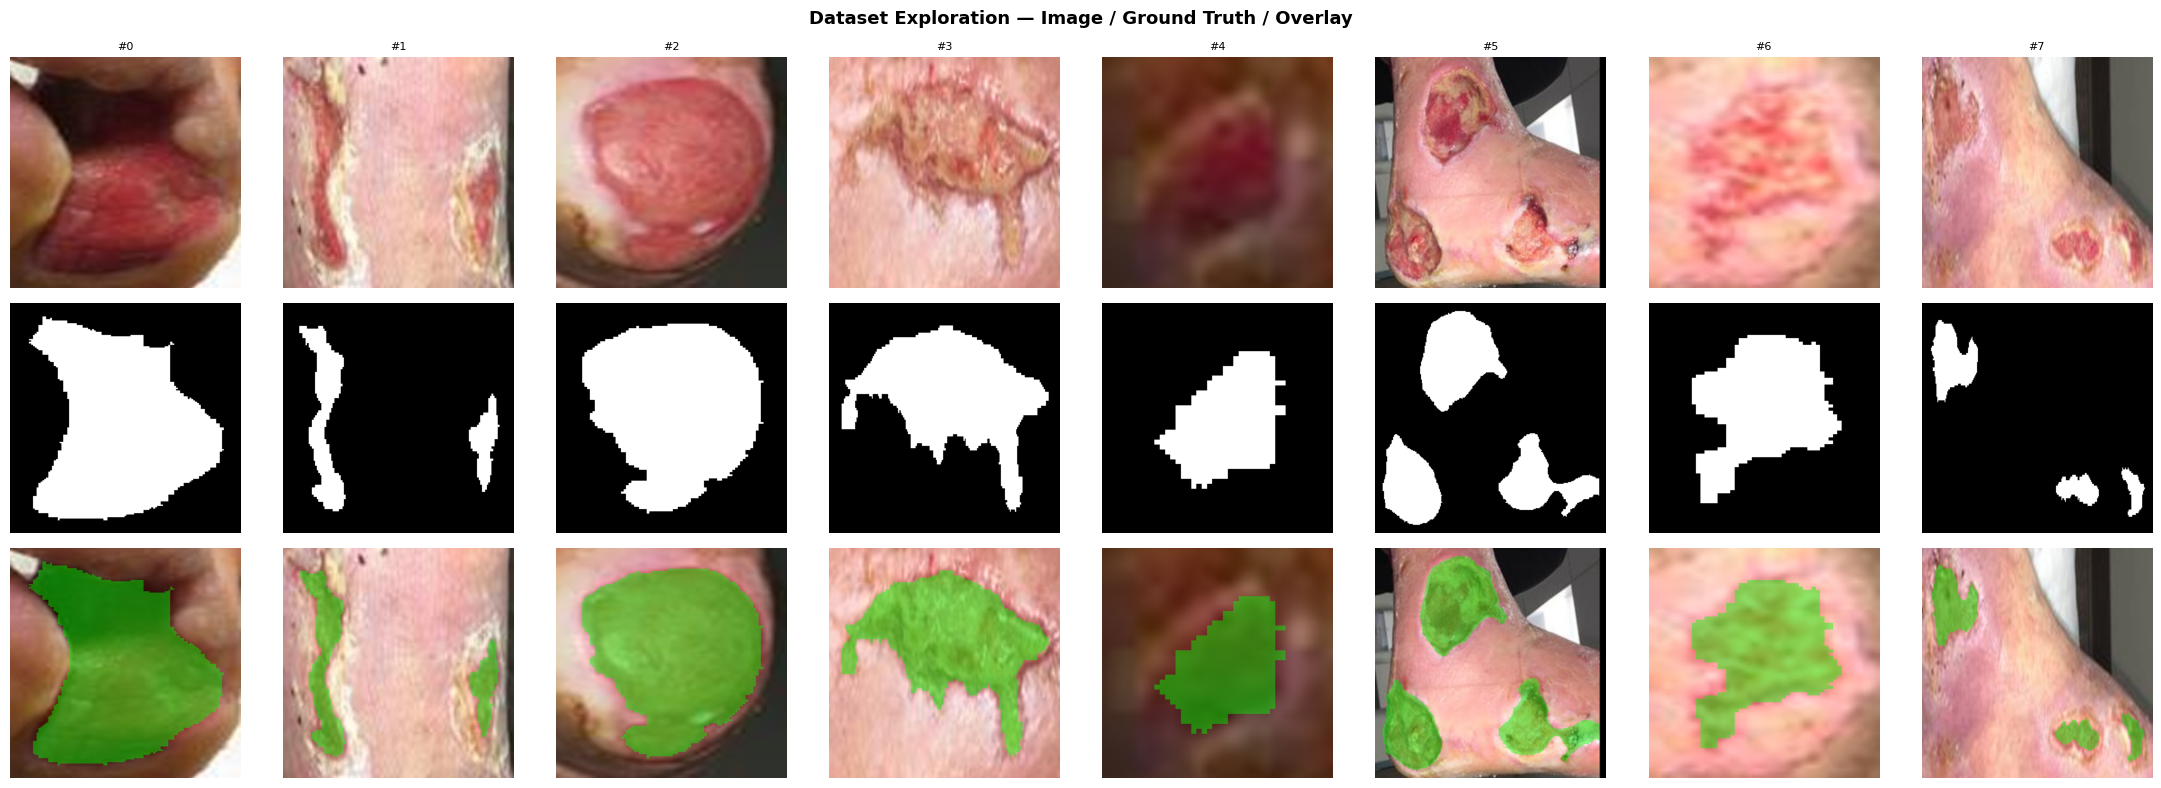

Saved data_exploration.png


In [4]:
def denorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

def overlay_mask(img_np, mask_np, alpha=0.45):
    out = img_np.copy()
    out[mask_np > 0] = out[mask_np > 0] * (1 - alpha) + np.array([0, 1, 0]) * alpha
    return out.clip(0, 1)

sample_idx = []
for i in range(len(full_ds_noaug)):
    _, m = full_ds_noaug[i]
    if m.sum() > 0:
        sample_idx.append(i)
    if len(sample_idx) == 8:
        break

fig, axes = plt.subplots(3, 8, figsize=(22, 8))
fig.suptitle("Dataset Exploration — Image / Ground Truth / Overlay", fontsize=13, fontweight="bold")
for col, idx in enumerate(sample_idx):
    img_t, mask_t = full_ds_noaug[idx]
    img_np  = denorm(img_t)
    mask_np = mask_t[0].numpy()
    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f"#{idx}", fontsize=8)
    axes[1, col].imshow(mask_np, cmap="gray")
    axes[2, col].imshow(overlay_mask(img_np, mask_np))
    for r in range(3):
        axes[r, col].axis("off")

axes[0, 0].set_ylabel("Image",        fontsize=9, labelpad=6)
axes[1, 0].set_ylabel("Ground Truth", fontsize=9, labelpad=6)
axes[2, 0].set_ylabel("Overlay",      fontsize=9, labelpad=6)
plt.tight_layout()
plt.savefig("data_exploration.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved data_exploration.png")


## 4. Model Architecture

In [5]:
# SSM Block
class SSMBlock(nn.Module):
    def __init__(self, dim, d_state=16, d_conv=4, expand=2):
        super().__init__()
        d_inner       = int(expand * dim)
        self.d_inner  = d_inner
        self.d_state  = d_state
        self.norm     = nn.LayerNorm(dim)
        self.in_proj  = nn.Linear(dim, d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(d_inner, d_inner, kernel_size=d_conv,
                                  padding=d_conv - 1, groups=d_inner, bias=True)
        self.act      = nn.SiLU()
        self.x_proj   = nn.Linear(d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj  = nn.Linear(1, d_inner, bias=True)
        self.out_proj = nn.Linear(d_inner, dim, bias=False)
        self.dropout  = nn.Dropout(DROPOUT_RATE)
        a_log = (torch.log(torch.arange(1, d_state + 1).float())
                 .unsqueeze(0).expand(d_inner, -1).contiguous())
        self.A_log = nn.Parameter(a_log)
        self.D     = nn.Parameter(torch.ones(d_inner))
        nn.init.normal_(self.dt_proj.weight, std=0.01)
        nn.init.zeros_(self.dt_proj.bias)

    def forward(self, x):
        residual = x
        x        = self.norm(x)
        B, L, C  = x.shape
        x_in, z  = self.in_proj(x).chunk(2, dim=-1)
        x_in     = self.conv1d(x_in.transpose(1, 2))[..., :L].transpose(1, 2)
        x_in     = self.act(x_in)
        dt_raw, _, _ = torch.split(self.x_proj(x_in),
                                   [1, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt_raw.clamp(-4, 4)))
        y  = x_in * self.D + (x_in * torch.sigmoid(dt)).cumsum(dim=1) / max(L, 1)
        return self.dropout(self.out_proj(y * torch.sigmoid(z))) + residual


# Deep Vision Mamba Context Block
class DeepVisionMambaBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.norm = nn.GroupNorm(32, in_channels)
        self.ssm  = SSMBlock(in_channels)
        self.proj = nn.Conv2d(in_channels, in_channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        shortcut   = x
        x = self.norm(x)
        x = self.ssm(x.flatten(2).transpose(1, 2))
        x = self.proj(x.transpose(1, 2).reshape(B, C, H, W))
        return x + shortcut


# ResNet-50 Encoder
class ResNet50Encoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        rn = models.resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V1 if pretrained else None)
        self.stage0 = nn.Sequential(rn.conv1, rn.bn1, rn.relu, rn.maxpool)
        self.stage1 = rn.layer1
        self.stage2 = rn.layer2
        self.stage3 = rn.layer3
        self.stage4 = rn.layer4

    def forward(self, x):
        s0 = self.stage0(x)
        s1 = self.stage1(s0)
        s2 = self.stage2(s1)
        s3 = self.stage3(s2)
        s4 = self.stage4(s3)
        return s1, s2, s3, s4


# Node Embedding
class NodeEmbedding(nn.Module):
    def __init__(self, in_channels=2048, node_dim=256, num_nodes=NUM_NODES):
        super().__init__()
        self.num_nodes = num_nodes
        self.proj      = nn.Linear(in_channels, node_dim)
        self.pos_emb   = nn.Embedding(num_nodes, node_dim)

    def forward(self, feat):
        B, C, H, W = feat.shape
        flat = feat.flatten(2).transpose(1, 2)
        N_sp = H * W
        if N_sp >= self.num_nodes:
            idx   = torch.linspace(0, N_sp - 1, self.num_nodes).long().to(feat.device)
            nodes = flat[:, idx, :]
        else:
            rep   = math.ceil(self.num_nodes / N_sp)
            nodes = flat.repeat(1, rep, 1)[:, :self.num_nodes, :]
        nodes = self.proj(nodes)
        nodes = nodes + self.pos_emb(
            torch.arange(self.num_nodes, device=feat.device)).unsqueeze(0)
        return nodes


# Static hyperedge adjacency matrices
def _build_static_adj(n=NUM_NODES, k=5):
    reg = torch.zeros(n, n)
    for g in [range(*NODE_BED), range(*NODE_EDGE),
              range(*NODE_PERILESION), range(*NODE_HEALTHY)]:
        g   = list(g)
        idx = torch.tensor(g)
        reg[idx.unsqueeze(1), idx.unsqueeze(0)] = 1.0
    bnd = torch.zeros(n, n)
    bi  = torch.arange(*NODE_BED)
    ei  = torch.arange(*NODE_EDGE)
    bnd[ei.unsqueeze(1), bi.unsqueeze(0)] = 1.0
    bnd[bi.unsqueeze(1), ei.unsqueeze(0)] = 1.0
    spa = torch.zeros(n, n)
    ii  = torch.arange(n)
    for d in range(-k, k + 1):
        spa[ii, (ii + d).clamp(0, n - 1)] = 1.0
    return reg, bnd, spa


def _feature_adj(nodes):
    nf  = F.normalize(nodes.detach().mean(0), dim=-1)
    col = (nf @ nf.T > 0.7).float()
    d   = torch.cdist(nf, nf, p=1)
    tex = (d / d.max().clamp(min=1e-8) < 0.3).float()
    return col, tex


def _safe_adj(adj):
    iso = (adj.sum(-1) == 0)
    if iso.any():
        adj = adj + torch.eye(adj.size(0), device=adj.device) * iso.float().unsqueeze(1)
    return adj


# Hyperedge Attention
class HEAttnLayer(nn.Module):
    def __init__(self, node_dim=256, heads=4, dropout=DROPOUT_RATE):
        super().__init__()
        self.attn    = nn.MultiheadAttention(node_dim, heads,
                                             dropout=dropout, batch_first=True)
        self.norm1   = nn.LayerNorm(node_dim)
        self.ffn     = nn.Sequential(
            nn.Linear(node_dim, node_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(node_dim * 2, node_dim),
        )
        self.norm2   = nn.LayerNorm(node_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, nodes, adj):
        adj  = _safe_adj(adj)
        N    = nodes.size(1)
        mask = torch.zeros(N, N, dtype=nodes.dtype, device=nodes.device)
        mask[adj == 0] = float("-inf")
        out, _ = self.attn(nodes, nodes, nodes, attn_mask=mask)
        nodes  = self.norm1(nodes + self.dropout(out))
        nodes  = self.norm2(nodes + self.dropout(self.ffn(nodes)))
        return nodes


class HyperedgeAttention(nn.Module):
    def __init__(self, node_dim=256, num_layers=3):
        super().__init__()
        self.layers  = nn.ModuleList([HEAttnLayer(node_dim) for _ in range(num_layers)])
        self.he_proj = nn.Linear(node_dim * 5, node_dim)

    def forward(self, nodes, adjs):
        outs = []
        for adj in adjs:
            h = nodes
            for layer in self.layers:
                h = layer(h, adj)
            outs.append(h)
        return self.he_proj(torch.cat(outs, dim=-1))


# Symbolic Rule Layer
class SymbolicRuleLayer(nn.Module):
    def __init__(self, node_dim=256):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(node_dim * 2, node_dim),
            nn.Sigmoid(),
        )

    def forward(self, nodes):
        bed_mean   = nodes[:, NODE_BED[0]:NODE_BED[1], :].mean(1, keepdim=True)
        bed_expand = bed_mean.expand(-1, NODE_EDGE[1] - NODE_EDGE[0], -1)
        edge_nodes = nodes[:, NODE_EDGE[0]:NODE_EDGE[1], :]
        g          = self.gate(torch.cat([edge_nodes, bed_expand], dim=-1))
        out        = nodes.clone()
        out[:, NODE_EDGE[0]:NODE_EDGE[1], :] = g * edge_nodes + (1 - g) * bed_expand
        return out


# Neurosymbolic Fusion
class NeurosymbolicFusion(nn.Module):
    def __init__(self, node_dim=256, feat_ch=2048, out_ch=256):
        super().__init__()
        self.Wq        = nn.Linear(node_dim, node_dim)
        self.Wk        = nn.Linear(node_dim, node_dim)
        self.Wv        = nn.Linear(node_dim, node_dim)
        self.gate      = nn.Linear(node_dim * 2, node_dim)
        self.node_proj = nn.Sequential(nn.Linear(node_dim, out_ch), nn.ReLU(inplace=True))
        self.feat_proj = nn.Conv2d(feat_ch, out_ch, 1)

    def forward(self, he, sym, bn):
        B, C, H, W = bn.shape
        scale = he.shape[-1] ** -0.5
        Q = F.normalize(self.Wq(he), dim=-1)
        K = F.normalize(self.Wk(sym), dim=-1)
        V = self.Wv(sym)
        cross = torch.softmax(Q @ K.transpose(-1, -2) * scale, dim=-1) @ V
        g     = torch.sigmoid(self.gate(torch.cat([he, cross], dim=-1)))
        fused = g * he + (1 - g) * cross
        node_ctx = self.node_proj(fused).mean(dim=1)
        node_ctx = node_ctx[:, :, None, None].expand(B, -1, H, W)
        bt = self.feat_proj(bn)
        return bt + node_ctx


# U-Net Decoder
class DecBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=DROPOUT_RATE):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.cv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            x = torch.cat([x, skip], dim=1)
        return self.cv(x)


class UNetDecoder(nn.Module):
    def __init__(self, fused_ch=256):
        super().__init__()
        self.d4   = DecBlock(fused_ch, 1024, 256)
        self.d3   = DecBlock(256,       512, 128)
        self.d2   = DecBlock(128,       256,  64)
        self.d1   = DecBlock( 64,         0,  32)
        self.d0   = DecBlock( 32,         0,  16)
        self.head = nn.Conv2d(16, 1, 1)

    def forward(self, f, s3, s2, s1):
        x = self.d4(f,  s3)
        x = self.d3(x,  s2)
        x = self.d2(x,  s1)
        x = self.d1(x)
        x = self.d0(x)
        return self.head(x)


# Full Model
class WoundSegModel1(nn.Module):
    def __init__(self, num_nodes=NUM_NODES, node_dim=256, pretrained=True):
        super().__init__()
        self.encoder  = ResNet50Encoder(pretrained)
        self.mamba    = DeepVisionMambaBlock(2048)
        self.node_emb = NodeEmbedding(2048, node_dim, num_nodes)
        self.he_attn  = HyperedgeAttention(node_dim, num_layers=3)
        self.sym_rule = SymbolicRuleLayer(node_dim)
        self.fusion   = NeurosymbolicFusion(node_dim, 2048, 256)
        self.decoder  = UNetDecoder(256)
        r, b, s = _build_static_adj(num_nodes)
        self.register_buffer("adj_region",   r)
        self.register_buffer("adj_boundary", b)
        self.register_buffer("adj_spatial",  s)

    def forward(self, x):
        s1, s2, s3, s4 = self.encoder(x)
        bn    = self.mamba(s4)
        nodes = self.node_emb(bn)
        ca, ta = _feature_adj(nodes)
        ca = ca.to(x.device)
        ta = ta.to(x.device)
        adjs   = [self.adj_region, self.adj_boundary, self.adj_spatial, ca, ta]
        he     = self.he_attn(nodes, adjs)
        sym    = self.sym_rule(nodes)
        fused  = self.fusion(he, sym, bn)
        logits = self.decoder(fused, s3, s2, s1)
        return F.interpolate(logits, x.shape[2:], mode="bilinear", align_corners=False)


model    = WoundSegModel1(pretrained=True).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total  = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters : {n_params / 1e6:.2f} M")
print(f"Total parameters     : {n_total  / 1e6:.2f} M")

with torch.no_grad():
    _dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _out   = model(_dummy)
    print(f"Output shape         : {tuple(_out.shape)}  (expected [2, 1, {IMG_SIZE}, {IMG_SIZE}])")
    del _dummy, _out
torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


Trainable parameters : 61.73 M
Total parameters     : 61.73 M
Output shape         : (2, 1, 512, 512)  (expected [2, 1, 512, 512])


## 5. Loss Function and Metrics

In [6]:
class BCEDiceLoss(nn.Module):
    """40% BCE + 60% soft Dice loss with numerical stability guard."""
    def __init__(self, bce_w=0.4, dice_w=0.6, smooth=1.0):
        super().__init__()
        self.bce_w  = bce_w
        self.dice_w = dice_w
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        if not torch.isfinite(logits).all():
            logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
        bce_loss  = self.bce(logits, targets)
        p         = torch.sigmoid(logits)
        inter     = (p * targets).sum((1, 2, 3))
        union     = p.sum((1, 2, 3)) + targets.sum((1, 2, 3))
        dice_loss = (1.0 - (2.0 * inter + self.smooth) / (union + self.smooth)).mean()
        return self.bce_w * bce_loss + self.dice_w * dice_loss


def hausdorff_distance_95(pred_np, gt_np):
    from scipy.spatial.distance import cdist as _cdist
    pred_b = pred_np.astype(bool)
    gt_b   = gt_np.astype(bool)
    if not pred_b.any() and not gt_b.any():
        return 0.0
    if not pred_b.any() or not gt_b.any():
        return np.nan
    pred_border = pred_b ^ binary_erosion(pred_b)
    gt_border   = gt_b   ^ binary_erosion(gt_b)
    py, px = np.where(pred_border)
    gy, gx = np.where(gt_border)
    pred_pts = np.stack([py, px], axis=1).astype(np.float32)
    gt_pts   = np.stack([gy, gx], axis=1).astype(np.float32)
    d_pg = _cdist(pred_pts, gt_pts).min(axis=1)
    d_gp = _cdist(gt_pts, pred_pts).min(axis=1)
    return float(np.percentile(np.concatenate([d_pg, d_gp]), 95))


@torch.no_grad()
def compute_metrics(logits, masks, threshold=0.5):
    p  = (torch.sigmoid(logits) > threshold).float()
    m  = masks
    tp = (p * m).sum((1, 2, 3))
    fp = (p * (1 - m)).sum((1, 2, 3))
    fn = ((1 - p) * m).sum((1, 2, 3))
    dice = (2 * tp + 1) / (2 * tp + fp + fn + 1)
    iou  = (tp + 1)     / (tp + fp + fn + 1)
    prec = (tp + 1)     / (tp + fp + 1)
    rec  = (tp + 1)     / (tp + fn + 1)
    hd_vals = []
    p_np = p.cpu().numpy().astype(np.uint8)
    m_np = m.cpu().numpy().astype(np.uint8)
    for i in range(p_np.shape[0]):
        hd = hausdorff_distance_95(p_np[i, 0], m_np[i, 0])
        if not np.isnan(hd):
            hd_vals.append(hd)
    hd95 = float(np.mean(hd_vals)) if hd_vals else 0.0
    return {
        "dice":      dice.mean().item(),
        "iou":       iou.mean().item(),
        "precision": prec.mean().item(),
        "recall":    rec.mean().item(),
        "hd95":      hd95,
    }

criterion = BCEDiceLoss()
print("Loss and metrics ready.")


Loss and metrics ready.


## 6. EMA, TTA, Optimiser, Scheduler

In [7]:
class EMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.decay   = decay
        self.shadow  = {k: v.clone().detach() for k, v in model.state_dict().items()}
        self._backup = {}

    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1.0 - self.decay) * v.detach()

    def apply(self, model):
        self._backup = {k: v.clone() for k, v in model.state_dict().items()}
        model.load_state_dict(self.shadow)

    def restore(self, model):
        if self._backup:
            model.load_state_dict(self._backup)


def tta_predict(model, img_t, n_aug=6):
    augs = [
        lambda x: x,
        lambda x: torch.flip(x, [-1]),
        lambda x: torch.flip(x, [-2]),
        lambda x: torch.rot90(x,  1, [-2, -1]),
        lambda x: torch.rot90(x,  2, [-2, -1]),
        lambda x: torch.rot90(x,  3, [-2, -1]),
    ]
    de_augs = [
        lambda x: x,
        lambda x: torch.flip(x, [-1]),
        lambda x: torch.flip(x, [-2]),
        lambda x: torch.rot90(x, -1, [-2, -1]),
        lambda x: torch.rot90(x, -2, [-2, -1]),
        lambda x: torch.rot90(x, -3, [-2, -1]),
    ]
    model.eval()
    preds = []
    with torch.no_grad():
        for aug, de in zip(augs[:n_aug], de_augs[:n_aug]):
            preds.append(de(torch.sigmoid(model(aug(img_t)))))
    return torch.stack(preds).mean(0)


def train_one_epoch(model, loader, optimizer, criterion, ema, epoch,
                    warmup_epochs=WARMUP_EPOCHS):
    model.train()
    total_loss  = 0.0
    clip_events = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        if not torch.isfinite(loss):
            print("  [warning] non-finite loss — skipping batch")
            continue
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        if grad_norm > 1.0:
            clip_events += 1
        optimizer.step()
        ema.update(model)
        total_loss += loss.item()
    n = max(len(loader), 1)
    return total_loss / n, clip_events


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    acc = {"dice": 0.0, "iou": 0.0, "precision": 0.0, "recall": 0.0, "hd95": 0.0}
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, masks)
        if torch.isfinite(loss):
            total_loss += loss.item()
        m = compute_metrics(logits, masks)
        for k in acc:
            acc[k] += m[k]
    n = max(len(loader), 1)
    return total_loss / n, {k: v / n for k, v in acc.items()}


def get_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = get_scheduler(optimizer, WARMUP_EPOCHS, NUM_EPOCHS)
ema       = EMA(model)
print("Optimiser, scheduler, EMA ready.")


Optimiser, scheduler, EMA ready.


## 7. Training Loop

In [8]:
history = {
    "train_loss": [], "train_dice": [], "train_iou": [],
    "val_loss":   [], "val_dice":   [], "val_iou":   [],
    "val_hd95":   [], "lr":         [],
}

best_score = 0.0
best_dice  = 0.0
best_iou   = 0.0
no_improve = 0
stop_epoch = NUM_EPOCHS

for epoch in range(1, NUM_EPOCHS + 1):
    torch.cuda.empty_cache()

    tr_loss, clip_events = train_one_epoch(model, train_loader, optimizer,
                                           criterion, ema, epoch)
    va_loss, va_met      = evaluate(model, val_loader, criterion)
    current_lr           = optimizer.param_groups[0]["lr"]
    scheduler.step()

    model.eval()
    tr_dice_acc = tr_iou_acc = 0.0
    n_tr_batches = 0
    with torch.no_grad():
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            m = compute_metrics(model(imgs), masks)
            tr_dice_acc  += m["dice"]
            tr_iou_acc   += m["iou"]
            n_tr_batches += 1
            if n_tr_batches >= 20:
                break
    tr_dice = tr_dice_acc / max(n_tr_batches, 1)
    tr_iou  = tr_iou_acc  / max(n_tr_batches, 1)
    model.train()

    history["train_loss"].append(tr_loss)
    history["train_dice"].append(tr_dice)
    history["train_iou"].append(tr_iou)
    history["val_loss"].append(va_loss)
    history["val_dice"].append(va_met["dice"])
    history["val_iou"].append(va_met["iou"])
    history["val_hd95"].append(va_met["hd95"])
    history["lr"].append(current_lr)

    combined = 0.5 * va_met["dice"] + 0.5 * va_met["iou"]
    marker   = ""
    if combined > best_score:
        best_score = combined
        best_dice  = va_met["dice"]
        best_iou   = va_met["iou"]
        torch.save(model.state_dict(), "best_model_model1.pth")
        no_improve = 0
        marker     = "  [saved]"
    else:
        no_improve += 1

    torch.save({
        "epoch":      epoch,
        "model":      model.state_dict(),
        "optimizer":  optimizer.state_dict(),
        "scheduler":  scheduler.state_dict(),
        "ema_shadow": ema.shadow,
        "best_score": best_score,
        "history":    history,
    }, "last_checkpoint_model1.pth")

    print(
        f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
        f"lr={current_lr:.2e} | "
        f"train_loss={tr_loss:.4f}  train_dice={tr_dice:.4f} | "
        f"val_loss={va_loss:.4f}  val_dice={va_met['dice']:.4f}  "
        f"val_iou={va_met['iou']:.4f}  val_hd95={va_met['hd95']:.2f} | "
        f"combined={combined:.4f}  patience={no_improve}/{PATIENCE}"
        f"{marker}"
    )

    if no_improve >= PATIENCE:
        stop_epoch = epoch
        print(f"\nEarly stopping at epoch {epoch}. No improvement for {PATIENCE} epochs.")
        break

print(f"\nBest Val  Dice={best_dice:.4f}  IoU={best_iou:.4f}  Combined={best_score:.4f}")
print(f"Training stopped at epoch {stop_epoch}/{NUM_EPOCHS}")


Epoch   1/50 | lr=2.00e-05 | train_loss=0.6245  train_dice=0.8521 | val_loss=0.5492  val_dice=0.8540  val_iou=0.7843  val_hd95=41.30 | combined=0.8192  patience=0/10  [saved]
Epoch   2/50 | lr=4.00e-05 | train_loss=0.5487  train_dice=0.8454 | val_loss=0.5267  val_dice=0.8240  val_iou=0.7551  val_hd95=40.42 | combined=0.7895  patience=1/10
Epoch   3/50 | lr=6.00e-05 | train_loss=0.5210  train_dice=0.8209 | val_loss=0.4860  val_dice=0.8261  val_iou=0.7602  val_hd95=36.10 | combined=0.7931  patience=2/10
Epoch   4/50 | lr=8.00e-05 | train_loss=0.4942  train_dice=0.8626 | val_loss=0.4609  val_dice=0.8213  val_iou=0.7615  val_hd95=32.08 | combined=0.7914  patience=3/10
Epoch   5/50 | lr=1.00e-04 | train_loss=0.4664  train_dice=0.8851 | val_loss=0.4328  val_dice=0.8805  val_iou=0.8177  val_hd95=33.66 | combined=0.8491  patience=0/10  [saved]
Epoch   6/50 | lr=1.00e-04 | train_loss=0.4392  train_dice=0.9045 | val_loss=0.4095  val_dice=0.9077  val_iou=0.8470  val_hd95=31.55 | combined=0.8773  

## 8. Training Curves

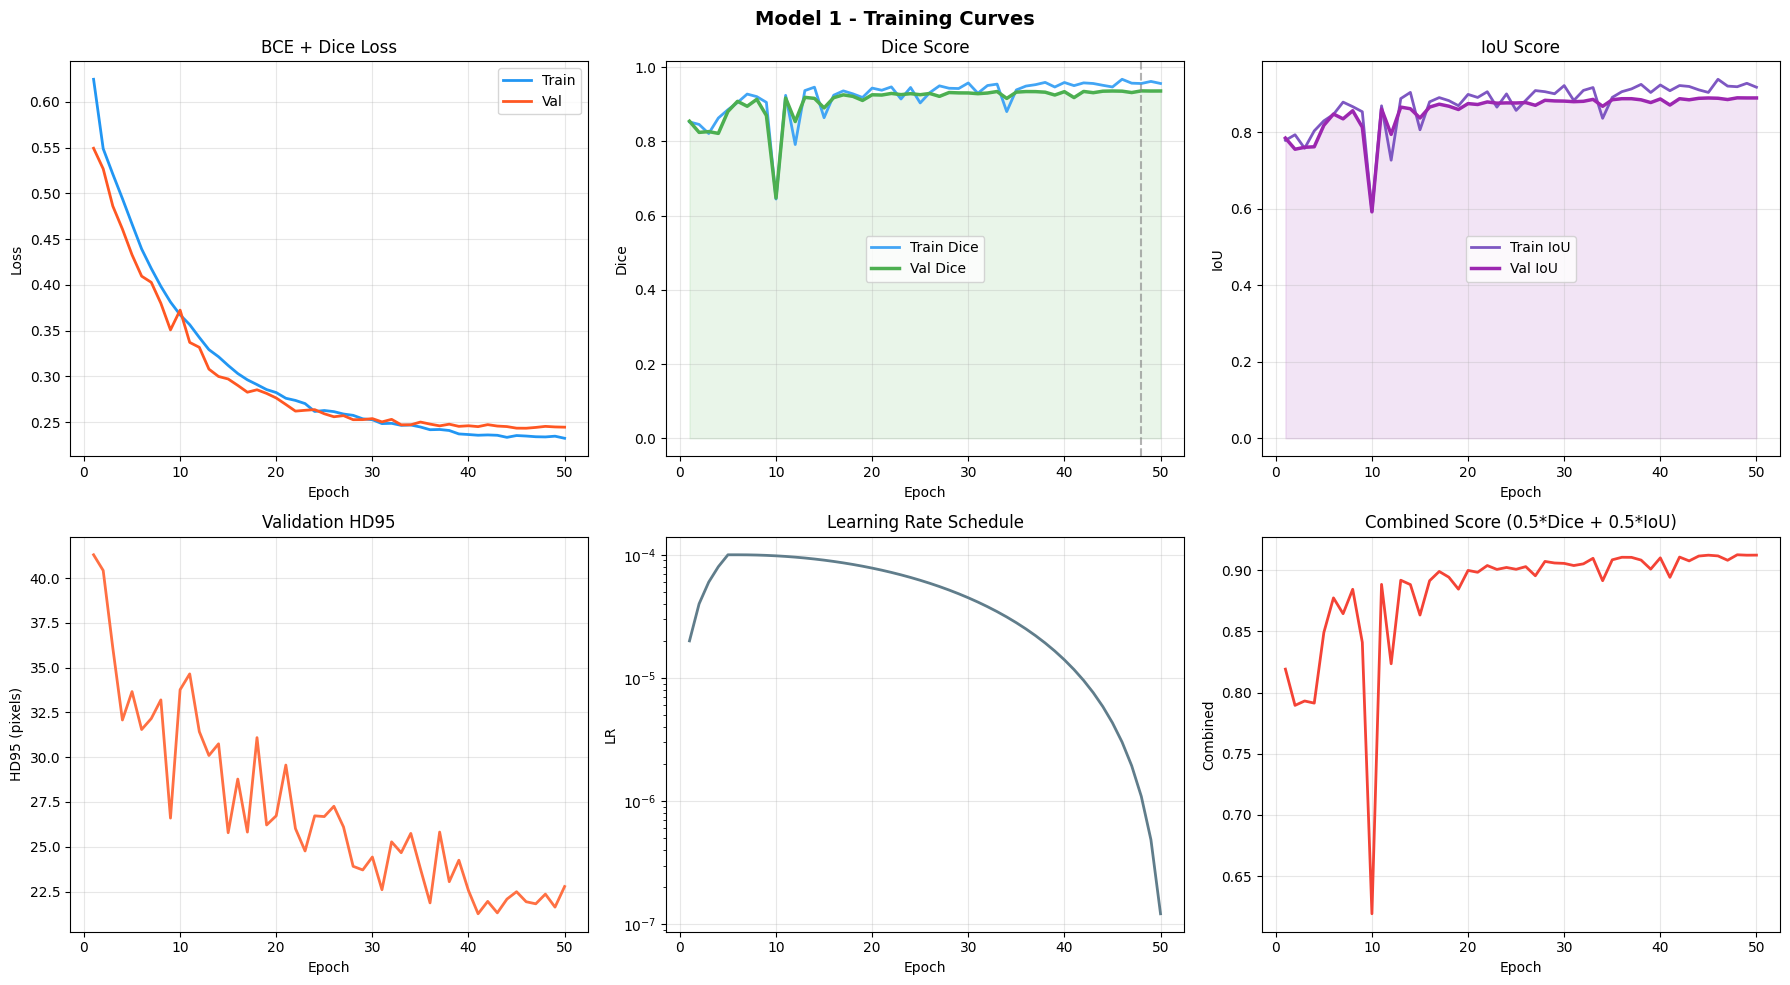

Saved training_curves.png


In [9]:
ep = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model 1 - Training Curves", fontsize=14, fontweight="bold")

axes[0,0].plot(ep, history["train_loss"], label="Train", color="#2196F3", linewidth=2)
axes[0,0].plot(ep, history["val_loss"],   label="Val",   color="#FF5722", linewidth=2)
axes[0,0].set_title("BCE + Dice Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Loss")
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep, history["train_dice"], label="Train Dice", color="#42A5F5", linewidth=2)
axes[0,1].plot(ep, history["val_dice"],   label="Val Dice",   color="#4CAF50", linewidth=2.5)
axes[0,1].fill_between(ep, history["val_dice"], alpha=0.12, color="#4CAF50")
best_e = int(np.argmax(history["val_dice"]))
axes[0,1].axvline(best_e + 1, color="gray", linestyle="--", alpha=0.6)
axes[0,1].set_title("Dice Score"); axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("Dice")
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[0,2].plot(ep, history["train_iou"], label="Train IoU", color="#7E57C2", linewidth=2)
axes[0,2].plot(ep, history["val_iou"],   label="Val IoU",   color="#9C27B0", linewidth=2.5)
axes[0,2].fill_between(ep, history["val_iou"], alpha=0.12, color="#9C27B0")
axes[0,2].set_title("IoU Score"); axes[0,2].set_xlabel("Epoch"); axes[0,2].set_ylabel("IoU")
axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

axes[1,0].plot(ep, history["val_hd95"], color="#FF7043", linewidth=2)
axes[1,0].set_title("Validation HD95"); axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("HD95 (pixels)")
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ep, history["lr"], color="#607D8B", linewidth=2)
axes[1,1].set_title("Learning Rate Schedule"); axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("LR")
axes[1,1].set_yscale("log"); axes[1,1].grid(alpha=0.3)

combined_hist = [0.5 * d + 0.5 * i for d, i in zip(history["val_dice"], history["val_iou"])]
axes[1,2].plot(ep, combined_hist, color="#F44336", linewidth=2)
axes[1,2].set_title("Combined Score (0.5*Dice + 0.5*IoU)")
axes[1,2].set_xlabel("Epoch"); axes[1,2].set_ylabel("Combined")
axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved training_curves.png")


## 9. Test Set Evaluation (EMA + 6-fold TTA)

In [10]:
model.load_state_dict(torch.load("best_model_model1.pth", map_location=DEVICE))
ema.apply(model)

test_metrics = {"dice": [], "iou": [], "precision": [], "recall": [], "hd95": []}
os.makedirs("test_predictions", exist_ok=True)

all_imgs  = []
all_masks = []
all_preds = []

model.eval()
for i, (imgs, masks) in enumerate(test_loader):
    imgs      = imgs.to(DEVICE)
    preds     = tta_predict(model, imgs, n_aug=6)
    preds_bin = (preds > 0.5).float()

    pred_np = (preds_bin[0, 0].cpu().numpy() * 255).astype(np.uint8)
    cv2.imwrite(f"test_predictions/pred_{i:04d}.png", pred_np)

    if masks.sum() > 0:
        masks_d       = masks.to(DEVICE)
        logits_approx = torch.log(
            preds.clamp(1e-6, 1.0 - 1e-6) / (1.0 - preds.clamp(1e-6, 1.0 - 1e-6))
        )
        m = compute_metrics(logits_approx, masks_d)
        for k in test_metrics:
            test_metrics[k].append(m[k])

    if masks.sum() > 0 and len(all_imgs) < 12:
        all_imgs.append(imgs[0].cpu())
        all_masks.append(masks[0])
        all_preds.append(preds_bin[0].cpu())

n_eval = len(test_metrics["dice"])
print("-" * 60)
print("  Test Set Results  (EMA + 6-fold TTA)")
print("-" * 60)
print(f"  {'Metric':<14} {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print("-" * 60)
for k, v in test_metrics.items():
    arr = np.array(v)
    print(f"  {k.capitalize():<14} {arr.mean():>8.4f}  {arr.std():>8.4f}  "
          f"{arr.min():>8.4f}  {arr.max():>8.4f}")
print("-" * 60)
print(f"  Evaluated on {n_eval} labelled test samples")
print("-" * 60)

ema.restore(model)


------------------------------------------------------------
  Test Set Results  (EMA + 6-fold TTA)
------------------------------------------------------------
  Metric             Mean       Std       Min       Max
------------------------------------------------------------
  Dice             0.9365    0.0456    0.7459    0.9885
  Iou              0.8838    0.0751    0.5948    0.9773
  Precision        0.9412    0.0557    0.7024    1.0000
  Recall           0.9364    0.0657    0.6147    0.9974
  Hd95            21.7132   21.5274    4.0000  154.6366
------------------------------------------------------------
  Evaluated on 168 labelled test samples
------------------------------------------------------------


## 10. Metric Summary Chart

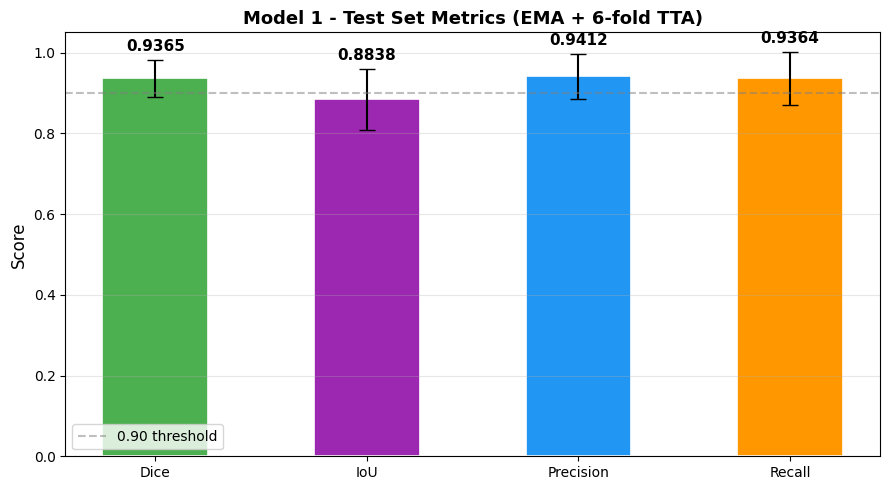

Saved metric_summary.png


In [11]:
metric_names = ["Dice", "IoU", "Precision", "Recall"]
metric_keys  = ["dice", "iou", "precision", "recall"]
means  = [np.mean(test_metrics[k]) for k in metric_keys]
stds   = [np.std(test_metrics[k])  for k in metric_keys]
colors = ["#4CAF50", "#9C27B0", "#2196F3", "#FF9800"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metric_names, means, yerr=stds, capsize=6,
              color=colors, edgecolor="white", linewidth=1.2, width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model 1 - Test Set Metrics (EMA + 6-fold TTA)", fontsize=13, fontweight="bold")
ax.axhline(0.9, color="gray", linestyle="--", alpha=0.5, label="0.90 threshold")
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2.0, mean + std + 0.015,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("metric_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved metric_summary.png")


## 11. Prediction Grid -- Image / Ground Truth / Prediction / Difference

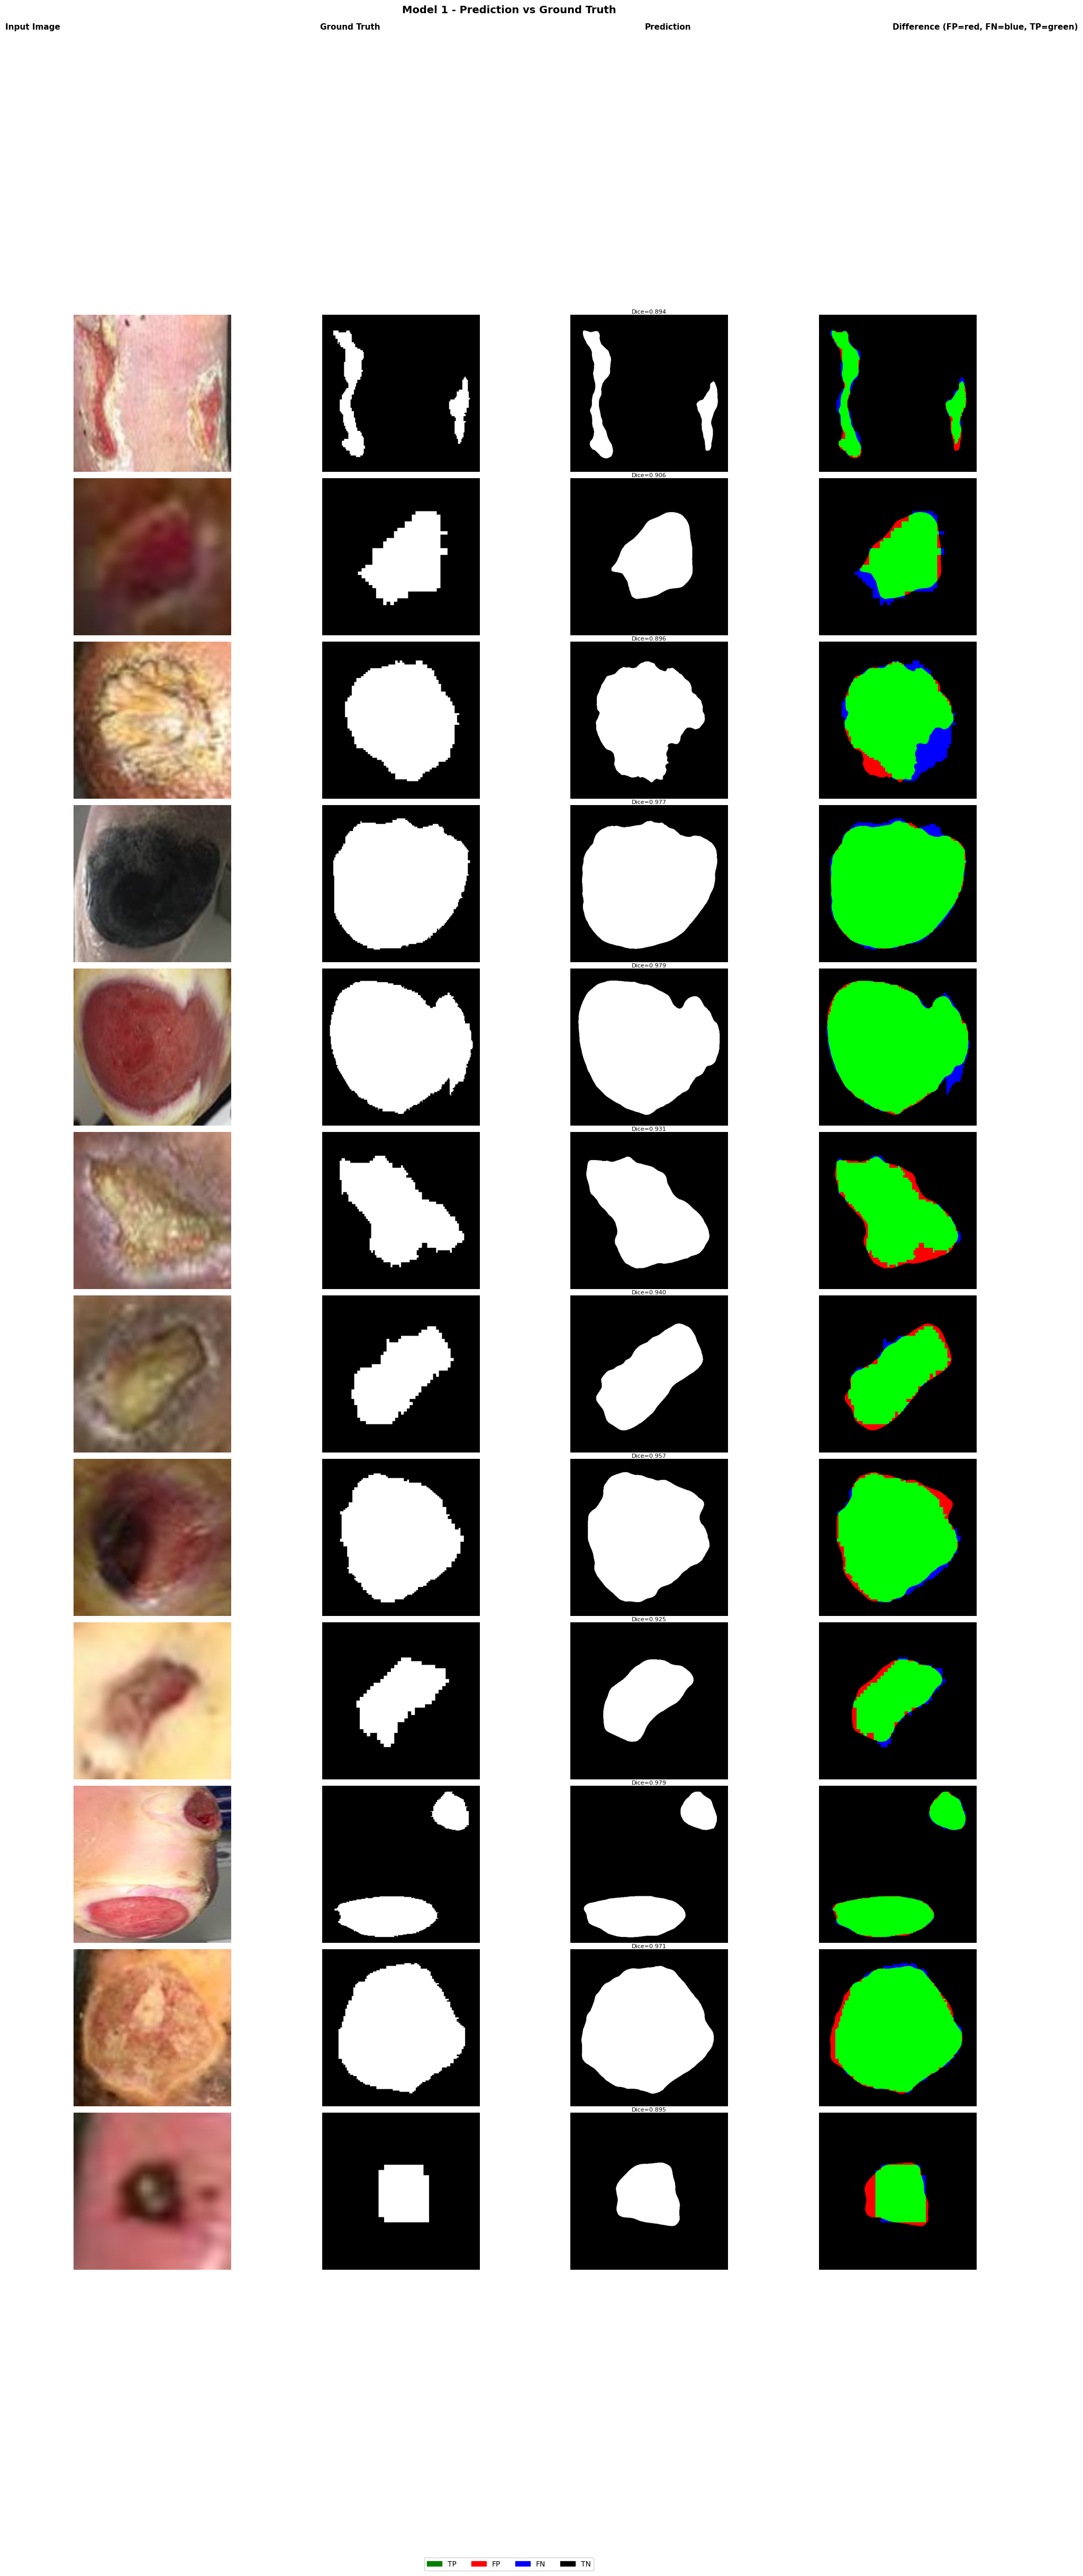

Saved prediction_grid.png


In [12]:
n_show = min(len(all_imgs), 12)
fig    = plt.figure(figsize=(24, n_show * 4))
gs     = GridSpec(n_show, 4, figure=fig, hspace=0.04, wspace=0.04)

col_titles = ["Input Image", "Ground Truth", "Prediction", "Difference (FP=red, FN=blue, TP=green)"]
for c, t in enumerate(col_titles):
    fig.text((c + 0.5) / 4.0, 0.995, t, ha="center", va="top",
             fontsize=11, fontweight="bold")

for row in range(n_show):
    img_np  = denorm(all_imgs[row])
    gt_np   = all_masks[row][0].numpy()
    pred_np = all_preds[row][0].numpy()

    diff = np.zeros((*gt_np.shape, 3))
    diff[(pred_np == 1) & (gt_np == 0)] = [1, 0, 0]
    diff[(pred_np == 0) & (gt_np == 1)] = [0, 0, 1]
    diff[(pred_np == 1) & (gt_np == 1)] = [0, 1, 0]

    for col, data, cmap, vrange in [
        (0, img_np,  None,   None),
        (1, gt_np,   "gray", (0, 1)),
        (2, pred_np, "gray", (0, 1)),
        (3, diff,    None,   None),
    ]:
        ax = fig.add_subplot(gs[row, col])
        kw = dict(cmap=cmap) if cmap else {}
        if vrange:
            kw.update(vmin=vrange[0], vmax=vrange[1])
        ax.imshow(data, **kw)
        ax.axis("off")
        if col == 2:
            p_t   = torch.tensor(pred_np).unsqueeze(0).unsqueeze(0)
            g_t   = torch.tensor(gt_np).unsqueeze(0).unsqueeze(0)
            inter = (p_t * g_t).sum()
            union = p_t.sum() + g_t.sum()
            d     = (2 * inter + 1) / (union + 1)
            ax.set_title(f"Dice={d:.3f}", fontsize=8, pad=2)

patches = [
    mpatches.Patch(color="green", label="TP"),
    mpatches.Patch(color="red",   label="FP"),
    mpatches.Patch(color="blue",  label="FN"),
    mpatches.Patch(color="black", label="TN"),
]
fig.legend(handles=patches, loc="lower center", ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.01), framealpha=0.9)
plt.suptitle("Model 1 - Prediction vs Ground Truth", fontsize=14,
             fontweight="bold", y=1.002)
plt.savefig("prediction_grid.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved prediction_grid.png")


## 12. Per-Sample Score Distribution

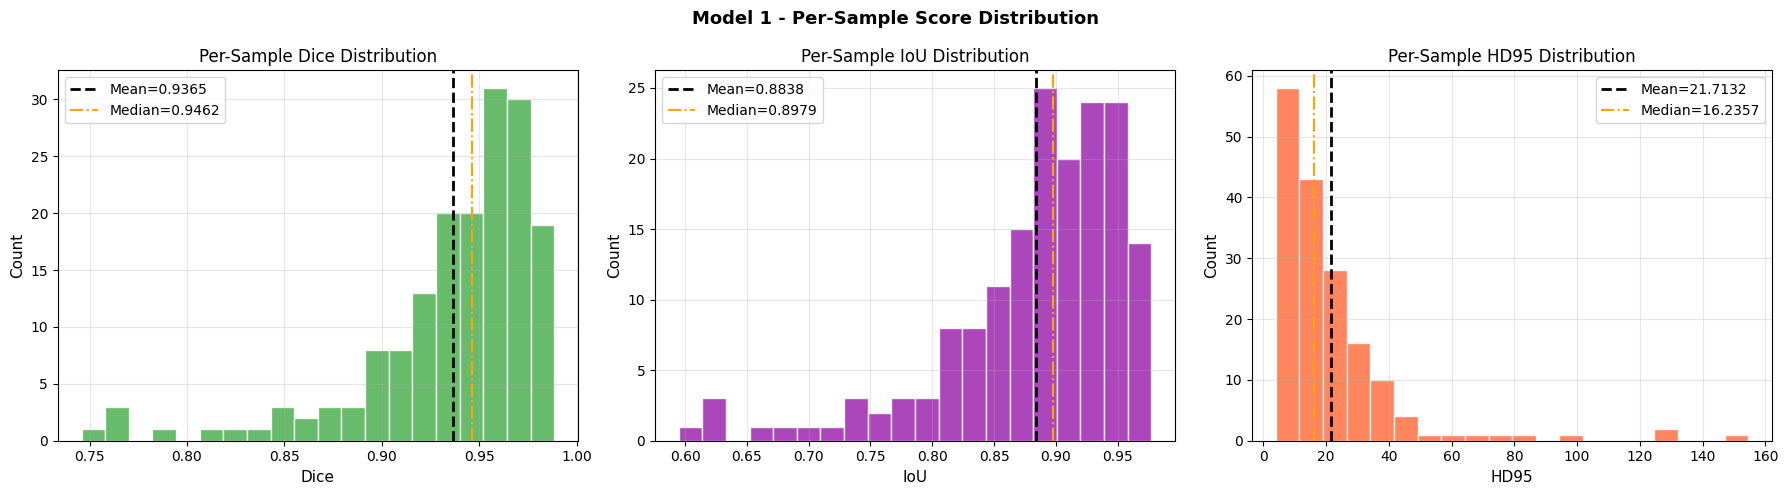

Saved score_distribution.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model 1 - Per-Sample Score Distribution", fontsize=13, fontweight="bold")

for ax, key, label, color in [
    (axes[0], "dice", "Dice", "#4CAF50"),
    (axes[1], "iou",  "IoU",  "#9C27B0"),
    (axes[2], "hd95", "HD95", "#FF7043"),
]:
    arr = np.array(test_metrics[key])
    ax.hist(arr, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(arr.mean(),     color="black",  linestyle="--", linewidth=2,
               label=f"Mean={arr.mean():.4f}")
    ax.axvline(np.median(arr), color="orange", linestyle="-.", linewidth=1.5,
               label=f"Median={np.median(arr):.4f}")
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"Per-Sample {label} Distribution")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("score_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved score_distribution.png")


## 13. Save Results Summary

In [14]:
summary = {
    "architecture": "ResNet50 + VisionMamba + HyperedgeAttention + NeurosymbolicFusion",
    "datasets":     ["Foot Ulcer Segmentation Challenge", "Medetec_foot_ulcer_22"],
    "total_images": len(full_ds_noaug),
    "split": {
        "train": len(train_indices),
        "val":   len(val_indices),
        "test":  len(test_indices),
    },
    "hyperparameters": {
        "img_size":      IMG_SIZE,
        "batch_size":    BATCH_SIZE,
        "lr":            LR,
        "warmup_epochs": WARMUP_EPOCHS,
        "ema_decay":     EMA_DECAY,
        "patience":      PATIENCE,
        "dropout":       DROPOUT_RATE,
        "loss":          "0.4*BCE + 0.6*Dice",
    },
    "training": {
        "epochs_run":    len(history["train_loss"]),
        "best_val_dice": float(best_dice),
        "best_val_iou":  float(best_iou),
        "best_combined": float(best_score),
    },
    "test_metrics": {
        k: {"mean": float(np.mean(v)), "std": float(np.std(v)),
            "min":  float(np.min(v)),  "max": float(np.max(v))}
        for k, v in test_metrics.items() if v
    },
    "training_history": {
        k: [float(x) for x in v] for k, v in history.items()
    },
}

with open("model1_results.json", "w") as f:
    json.dump(summary, f, indent=2)

print("-" * 56)
print("  MODEL 1 — FINAL SUMMARY")
print("-" * 56)
print(f"  Architecture   : ResNet-50 + Vision Mamba + Hyperedge Attention")
print(f"  Datasets       : FUSC + Medetec  ({len(full_ds_noaug)} total images)")
print(f"  Train/Val/Test : {len(train_indices)} / {len(val_indices)} / {len(test_indices)}")
print(f"  Epochs run     : {len(history['train_loss'])} / {NUM_EPOCHS}")
print(f"  Best Val Dice  : {best_dice:.4f}")
print(f"  Best Val IoU   : {best_iou:.4f}")
print(f"  Best Combined  : {best_score:.4f}")
if test_metrics["dice"]:
    print(f"  Test Dice      : {np.mean(test_metrics['dice']):.4f} +/- {np.std(test_metrics['dice']):.4f}")
    print(f"  Test IoU       : {np.mean(test_metrics['iou']):.4f} +/- {np.std(test_metrics['iou']):.4f}")
    print(f"  Test Precision : {np.mean(test_metrics['precision']):.4f}")
    print(f"  Test Recall    : {np.mean(test_metrics['recall']):.4f}")
    print(f"  Test HD95      : {np.mean(test_metrics['hd95']):.2f} px")
print("-" * 56)
print("  Saved: best_model_model1.pth")
print("         last_checkpoint_model1.pth")
print("         model1_results.json")
print("         training_curves.png")
print("         metric_summary.png")
print("         prediction_grid.png")
print("         score_distribution.png")
print("         test_predictions/")
print("-" * 56)


--------------------------------------------------------
  MODEL 1 — FINAL SUMMARY
--------------------------------------------------------
  Architecture   : ResNet-50 + Vision Mamba + Hyperedge Attention
  Datasets       : FUSC + Medetec  (1370 total images)
  Train/Val/Test : 913 / 228 / 229
  Epochs run     : 50 / 50
  Best Val Dice  : 0.9357
  Best Val IoU   : 0.8893
  Best Combined  : 0.9125
  Test Dice      : 0.9365 +/- 0.0456
  Test IoU       : 0.8838 +/- 0.0751
  Test Precision : 0.9412
  Test Recall    : 0.9364
  Test HD95      : 21.71 px
--------------------------------------------------------
  Saved: best_model_model1.pth
         last_checkpoint_model1.pth
         model1_results.json
         training_curves.png
         metric_summary.png
         prediction_grid.png
         score_distribution.png
         test_predictions/
--------------------------------------------------------


## 14. Test-Set Scoring Policy for Empty-Mask Images

The evaluation loop above scores only images where `masks.sum() > 0`, silently dropping wound-free images. This cell re-evaluates the full test set and prints both numbers side-by-side.

In [15]:
ema.apply(model)
model.eval()

full_test_metrics = {"dice": [], "iou": [], "precision": [], "recall": [], "hd95": []}
n_empty_gt = 0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        preds = tta_predict(model, imgs, n_aug=6)
        if masks.sum() == 0:
            n_empty_gt += 1
        masks_d = masks.to(DEVICE)
        la = torch.log(preds.clamp(1e-6, 1-1e-6) / (1 - preds.clamp(1e-6, 1-1e-6)))
        m  = compute_metrics(la, masks_d)
        for k in full_test_metrics:
            full_test_metrics[k].append(m[k])

ema.restore(model)

print(f"Lesion-only test images : {len(test_metrics['dice'])}")
print(f"Wound-free (empty GT)   : {n_empty_gt}")
print(f"Full test set           : {len(full_test_metrics['dice'])}")
print()
print(f"{'Metric':<12} {'Lesion-only':>14} {'Full test set':>16}")
print("-" * 44)
for k in full_test_metrics:
    lo = np.mean(test_metrics[k]) if test_metrics[k] else float("nan")
    fu = np.mean(full_test_metrics[k])
    print(f"{k.capitalize():<12} {lo:>14.4f} {fu:>16.4f}")

with open("model1_full_test_metrics.json", "w") as f:
    json.dump({k: [float(x) for x in v] for k, v in full_test_metrics.items()}, f, indent=2)
print("\nSaved model1_full_test_metrics.json")


Lesion-only test images : 168
Wound-free (empty GT)   : 61
Full test set           : 229

Metric          Lesion-only    Full test set
--------------------------------------------
Dice                 0.9365           0.9534
Iou                  0.8838           0.9148
Precision            0.9412           0.9569
Recall               0.9364           0.9533
Hd95                21.7132          15.9293

Saved model1_full_test_metrics.json


## 15. Bootstrap 95% Confidence Intervals

10,000-resample bootstrap CIs on per-sample test metrics. No retraining -- reuses the `test_metrics` arrays from Section 9.

In [16]:
def bootstrap_ci(values, n_boot=10000, ci=95, seed=SEED):
    values = np.asarray(values, dtype=np.float64)
    rng = np.random.default_rng(seed)
    boot_means = np.array([
        values[rng.integers(0, len(values), len(values))].mean()
        for _ in range(n_boot)
    ])
    lo = np.percentile(boot_means, (100-ci)/2)
    hi = np.percentile(boot_means, 100-(100-ci)/2)
    return values.mean(), lo, hi

ci_results = {}
print(f"{'Metric':<12} {'Mean':>8}  {'95% CI':>22}")
print("-" * 48)
for k, v in test_metrics.items():
    mean, lo, hi = bootstrap_ci(v)
    ci_results[k] = {"mean": float(mean), "ci_low": float(lo), "ci_high": float(hi)}
    print(f"{k.capitalize():<12} {mean:>8.4f}  [{lo:.4f}, {hi:.4f}]")

with open("model1_bootstrap_ci.json", "w") as f:
    json.dump(ci_results, f, indent=2)
print(f"\nSaved model1_bootstrap_ci.json")
print(f"\nPaper format: Dice = {ci_results['dice']['mean']:.4f} "
      f"(95% CI: {ci_results['dice']['ci_low']:.4f}-{ci_results['dice']['ci_high']:.4f})")


Metric           Mean                  95% CI
------------------------------------------------
Dice           0.9365  [0.9295, 0.9432]
Iou            0.8838  [0.8722, 0.8948]
Precision      0.9412  [0.9323, 0.9493]
Recall         0.9364  [0.9262, 0.9459]
Hd95          21.7132  [18.7041, 25.2121]

Saved model1_bootstrap_ci.json

Paper format: Dice = 0.9365 (95% CI: 0.9295-0.9432)


## 16. Model Complexity and Runtime Analysis

Parameter count by module, FLOPs, and measured inference latency.

In [17]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "thop",
                "--break-system-packages", "-q"], check=False)
try:
    from thop import profile as _thop_profile
    _HAS_THOP = True
except ImportError:
    _HAS_THOP = False
    print("thop not available -- FLOPs skipped.")

import time

model.eval()
modules = [
    ("encoder (ResNet-50)",            model.encoder),
    ("mamba (DeepVisionMamba)",         model.mamba),
    ("node_emb (NodeEmbedding)",        model.node_emb),
    ("he_attn (HyperedgeAttention)",    model.he_attn),
    ("sym_rule (SymbolicRuleLayer)",    model.sym_rule),
    ("fusion (NeurosymbolicFusion)",    model.fusion),
    ("decoder (UNetDecoder)",           model.decoder),
]

print("Parameter count by module:")
print("-" * 48)
module_params = {}
for name, mod in modules:
    n = sum(p.numel() for p in mod.parameters())
    module_params[name] = n
    print(f"  {name:<40} {n/1e6:>7.3f} M")
total = sum(module_params.values())
print("-" * 48)
print(f"  {'TOTAL':<40} {total/1e6:>7.3f} M")

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
flops_g = None
if _HAS_THOP:
    with torch.no_grad():
        macs, _ = _thop_profile(model, inputs=(dummy,), verbose=False)
    flops_g = macs * 2 / 1e9
    for m in model.modules():
        if hasattr(m, "total_ops"):    del m.total_ops
        if hasattr(m, "total_params"): del m.total_params
    print(f"\nFLOPs ({IMG_SIZE}x{IMG_SIZE} input): {flops_g:.2f} GFLOPs")

n_warmup, n_runs = 10, 50
with torch.no_grad():
    for _ in range(n_warmup): _ = model(dummy)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_runs): _ = model(dummy)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    t1 = time.perf_counter()

latency_ms = (t1 - t0) / n_runs * 1000
fps = 1000.0 / latency_ms
print(f"\nInference latency (single image, no TTA) : {latency_ms:.2f} ms  ({fps:.2f} FPS)")
print(f"With 6-fold TTA (used at test time)       : ~{latency_ms*6:.2f} ms")

eff = {"total_params_M": total/1e6,
       "module_params_M": {k: v/1e6 for k,v in module_params.items()},
       "flops_G": flops_g,
       "latency_ms": latency_ms, "fps": fps,
       "img_size": IMG_SIZE, "device": str(DEVICE)}
with open("model1_efficiency.json", "w") as f:
    json.dump(eff, f, indent=2)
print("Saved model1_efficiency.json")


Parameter count by module:
------------------------------------------------
  encoder (ResNet-50)                       23.508 M
  mamba (DeepVisionMamba)                   29.604 M
  node_emb (NodeEmbedding)                   0.550 M
  he_attn (HyperedgeAttention)               1.909 M
  sym_rule (SymbolicRuleLayer)               0.131 M
  fusion (NeurosymbolicFusion)               0.919 M
  decoder (UNetDecoder)                      5.108 M
------------------------------------------------
  TOTAL                                     61.729 M

FLOPs (512x512 input): 91.15 GFLOPs

Inference latency (single image, no TTA) : 47.03 ms  (21.26 FPS)
With 6-fold TTA (used at test time)       : ~282.16 ms
Saved model1_efficiency.json


## 17. Explainability - Symbolic Gate and Hyperedge Attention

Hooks into the learned gate of `SymbolicRuleLayer` to show what the symbolic reasoning component is doing on real test images.

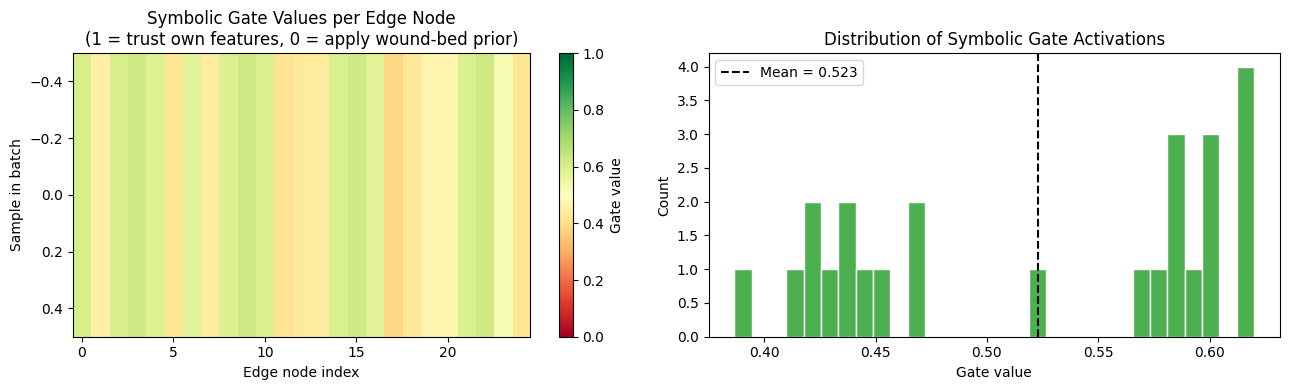

Mean gate value : 0.5230  (trusts own features)
Saved symbolic_gate_model1.png


In [18]:
_captured = {}

def _gate_hook(module, inp, out):
    _captured["gate_values"] = out.detach().cpu()

hook_handle = model.sym_rule.gate.register_forward_hook(_gate_hook)

ema.apply(model)
model.eval()
sample_imgs, sample_masks = next(iter(test_loader))
sample_imgs = sample_imgs.to(DEVICE)
with torch.no_grad():
    _ = model(sample_imgs)
hook_handle.remove()
ema.restore(model)

gate_vals = _captured["gate_values"]          # (B, num_edge_nodes, node_dim)
gate_mean_per_node = gate_vals.mean(-1)        # (B, num_edge_nodes)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].imshow(gate_mean_per_node.numpy(), aspect="auto",
                     cmap="RdYlGn", vmin=0, vmax=1)
axes[0].set_xlabel("Edge node index")
axes[0].set_ylabel("Sample in batch")
axes[0].set_title("Symbolic Gate Values per Edge Node\n"
                   "(1 = trust own features, 0 = apply wound-bed prior)")
plt.colorbar(im, ax=axes[0], label="Gate value")

axes[1].hist(gate_mean_per_node.numpy().flatten(), bins=30,
             color="#4CAF50", edgecolor="white")
axes[1].axvline(gate_mean_per_node.mean().item(), color="black",
                linestyle="--",
                label=f"Mean = {gate_mean_per_node.mean().item():.3f}")
axes[1].set_xlabel("Gate value")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Symbolic Gate Activations")
axes[1].legend()

plt.tight_layout()
plt.savefig("symbolic_gate_model1.png", dpi=150, bbox_inches="tight")
plt.show()

mean_val = gate_mean_per_node.mean().item()
direction = "trusts own features" if mean_val > 0.5 else "pulls toward wound-bed prior"
print(f"Mean gate value : {mean_val:.4f}  ({direction})")
print("Saved symbolic_gate_model1.png")


## 18. Hypergraph Visualization

Two figures for the paper:

(a) Spatial overlay -- 100 graph nodes projected back onto a real wound image, colored by region type, with all five hyperedge types drawn from the real adjacency matrices.

(b) Abstract schematic for the Methodology section.

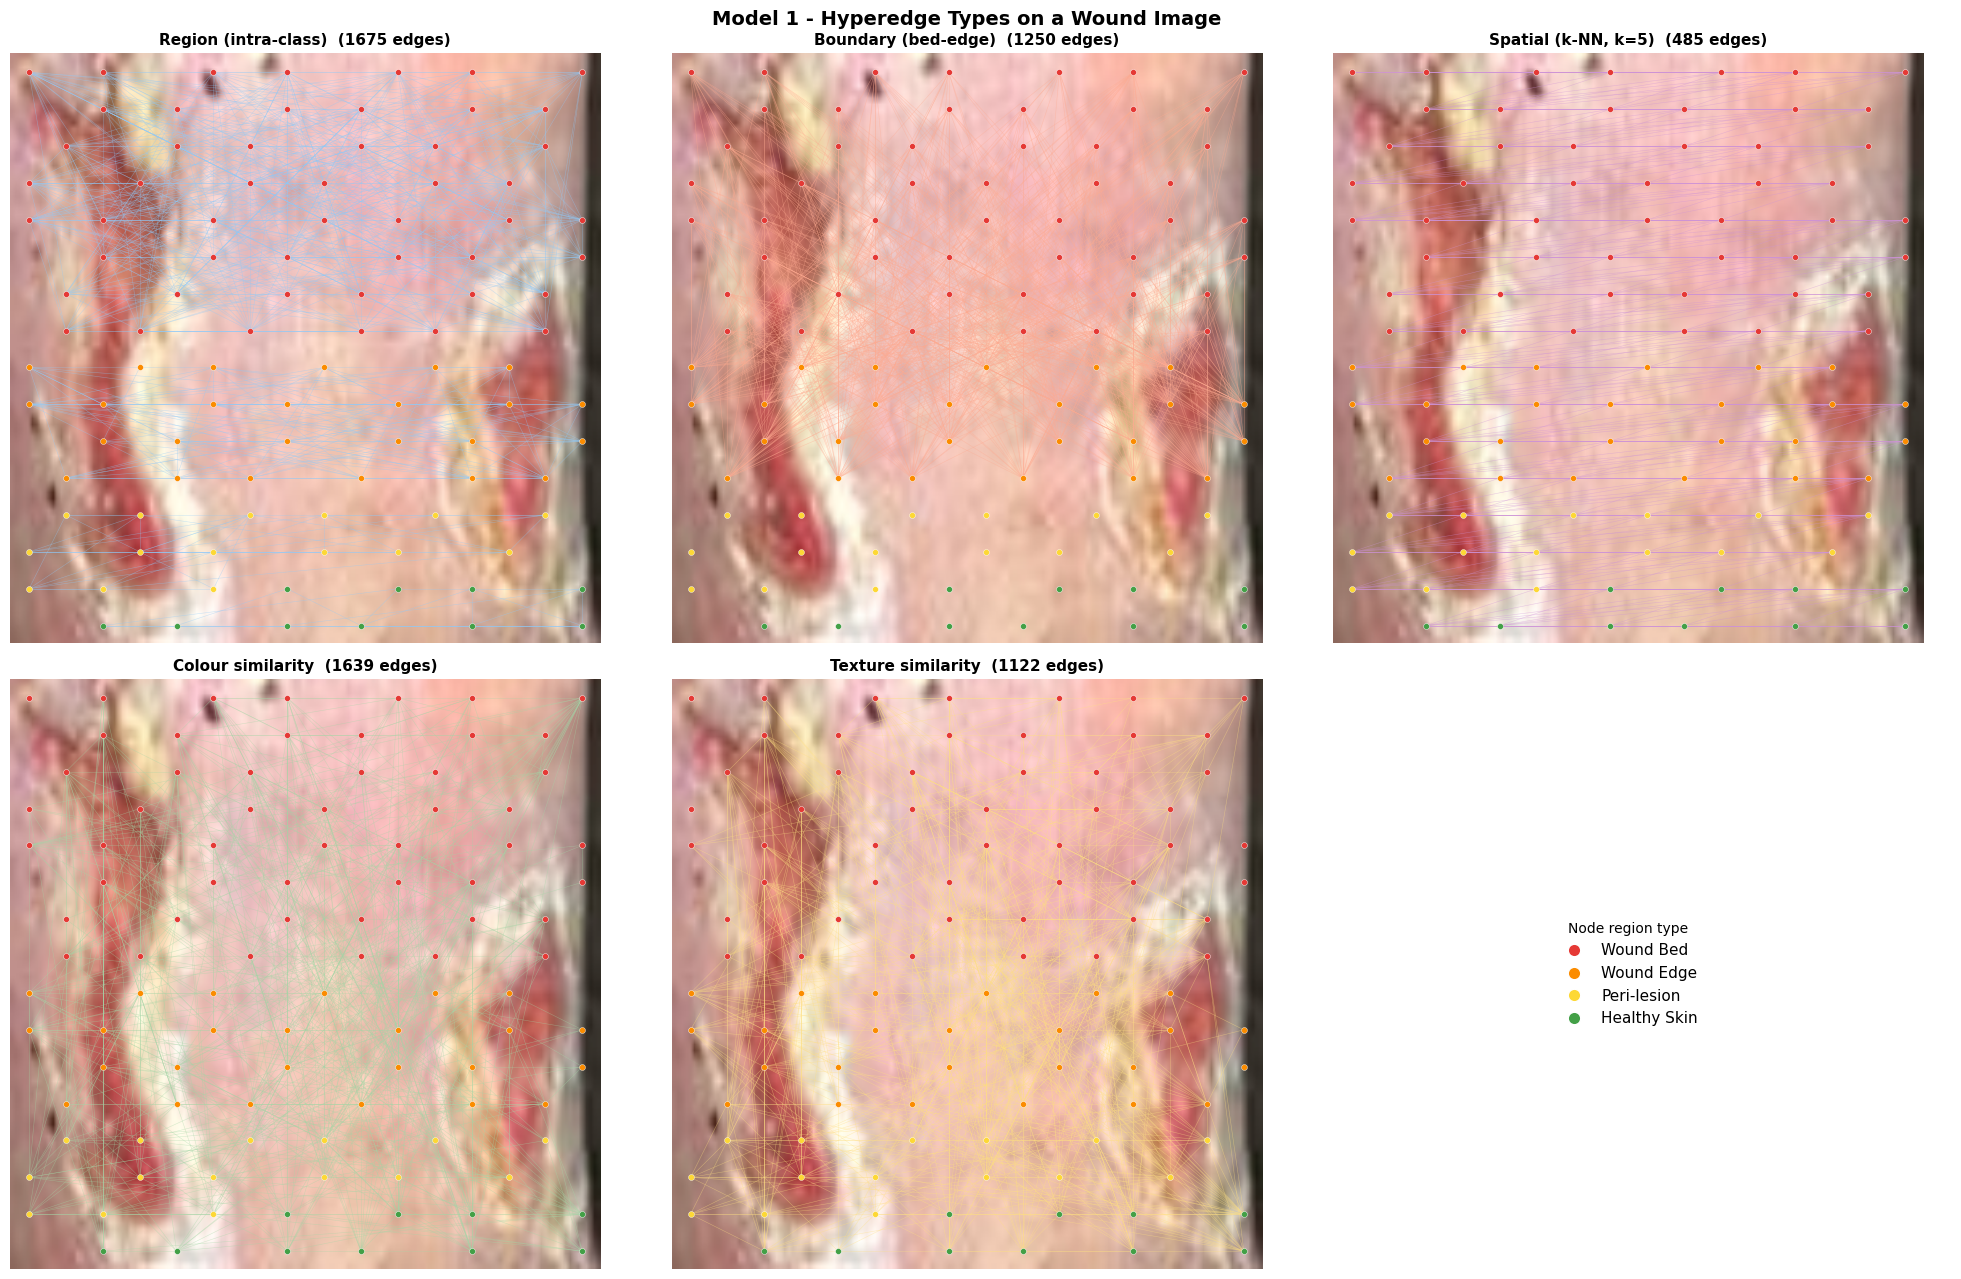

Saved hypergraph_all_edge_types_model1.png


In [19]:
try:
    import networkx as nx
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "networkx",
                    "--break-system-packages", "-q"], check=True)
    import networkx as nx

# Recover pixel-space node positions.
# ResNet-50 stage4 stride = 32, feature map = IMG_SIZE/32 per side.
FEAT_SIZE = IMG_SIZE // 32
N_SPATIAL = FEAT_SIZE * FEAT_SIZE
STRIDE    = IMG_SIZE / FEAT_SIZE

node_idx  = torch.linspace(0, N_SPATIAL - 1, NUM_NODES).long()
node_rows = (node_idx // FEAT_SIZE).numpy()
node_cols = (node_idx %  FEAT_SIZE).numpy()
node_px_y = node_rows * STRIDE + STRIDE / 2
node_px_x = node_cols * STRIDE + STRIDE / 2

region_of_node = np.empty(NUM_NODES, dtype=object)
region_of_node[NODE_BED[0]:NODE_BED[1]]              = "Wound Bed"
region_of_node[NODE_EDGE[0]:NODE_EDGE[1]]             = "Wound Edge"
region_of_node[NODE_PERILESION[0]:NODE_PERILESION[1]] = "Peri-lesion"
region_of_node[NODE_HEALTHY[0]:NODE_HEALTHY[1]]       = "Healthy Skin"

region_colors = {
    "Wound Bed":    "#E53935",
    "Wound Edge":   "#FB8C00",
    "Peri-lesion":  "#FDD835",
    "Healthy Skin": "#43A047",
}

# Pick a representative test image
ema.apply(model)
model.eval()
viz_img, viz_mask = None, None
for imgs, masks in test_loader:
    if masks[0].sum() > 500:
        viz_img, viz_mask = imgs[0], masks[0]
        break

img_np_viz  = denorm(viz_img)
mask_np_viz = viz_mask[0].numpy()

with torch.no_grad():
    s1, s2, s3, s4 = model.encoder(viz_img.unsqueeze(0).to(DEVICE))
    bn    = model.mamba(s4)
    nodes = model.node_emb(bn)
    ca, ta = _feature_adj(nodes)

adj_region   = model.adj_region.cpu().numpy()
adj_boundary = model.adj_boundary.cpu().numpy()
adj_spatial  = model.adj_spatial.cpu().numpy()
adj_color    = ca.cpu().numpy()
adj_texture  = ta.cpu().numpy()
ema.restore(model)

# --- Figure (a): all 5 edge types, one panel each ---
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

edge_sets = [
    ("Region (intra-class)",   adj_region,   "#90CAF9"),
    ("Boundary (bed-edge)",    adj_boundary, "#FFAB91"),
    ("Spatial (k-NN, k=5)",   adj_spatial,  "#CE93D8"),
    ("Colour similarity",      adj_color,    "#A5D6A7"),
    ("Texture similarity",     adj_texture,  "#FFE082"),
]

for ax, (label, adj, edge_color) in zip(axes, edge_sets):
    ax.imshow(img_np_viz)
    ii, jj = np.where(np.triu(adj, k=1) > 0)
    if len(ii) > 600:
        sel = np.random.default_rng(SEED).choice(len(ii), 600, replace=False)
        ii, jj = ii[sel], jj[sel]
    for a, b in zip(ii, jj):
        ax.plot([node_px_x[a], node_px_x[b]], [node_px_y[a], node_px_y[b]],
                color=edge_color, linewidth=0.4, alpha=0.45, zorder=2)
    for region, color in region_colors.items():
        sel = region_of_node == region
        ax.scatter(node_px_x[sel], node_px_y[sel], c=color, s=18,
                   edgecolors="white", linewidths=0.3, zorder=3)
    n_edges = int((adj.sum() - np.trace(adj)) / 2)
    ax.set_title(f"{label}  ({n_edges} edges)", fontsize=11, fontweight="bold")
    ax.axis("off")

axes[-1].axis("off")
handles = [plt.Line2D([0],[0], marker="o", color="w",
                       markerfacecolor=c, markersize=9, label=r)
           for r, c in region_colors.items()]
axes[-1].legend(handles=handles, loc="center", fontsize=11,
                title="Node region type", frameon=False)

plt.suptitle("Model 1 - Hyperedge Types on a Wound Image",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("hypergraph_all_edge_types_model1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved hypergraph_all_edge_types_model1.png")


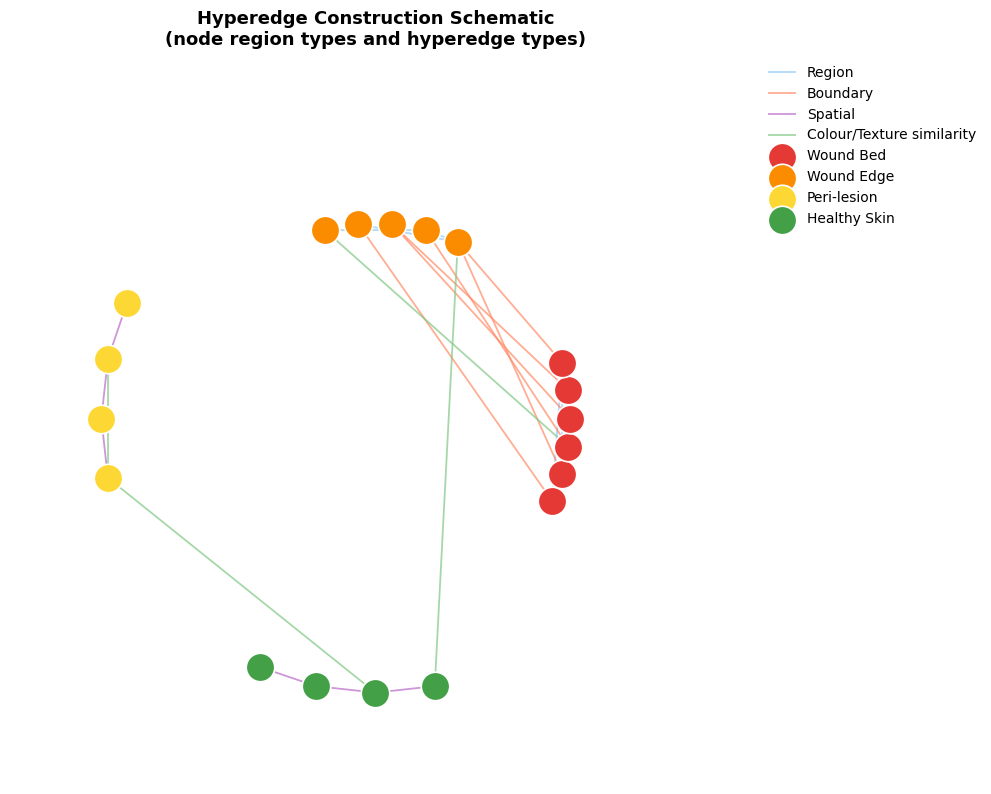

Saved hypergraph_schematic_model1.png


In [20]:
# --- Figure (b): abstract schematic for Methodology section ---
G = nx.Graph()
region_node_counts  = {"Wound Bed": 6, "Wound Edge": 5, "Peri-lesion": 4, "Healthy Skin": 4}
region_angle_offset = {"Wound Bed": 0, "Wound Edge": 90, "Peri-lesion": 180, "Healthy Skin": 270}

pos = {}
node_region_map = {}
gid = 0
for region, count in region_node_counts.items():
    base_angle = np.deg2rad(region_angle_offset[region])
    spread     = np.deg2rad(50)
    for k in range(count):
        angle  = base_angle + (k - count/2) * (spread/count)
        radius = 3.2 if region in ("Wound Bed", "Wound Edge") else 4.5
        node_id = f"{region[:1]}{k}_{gid}"
        G.add_node(node_id)
        pos[node_id] = (radius*np.cos(angle), radius*np.sin(angle))
        node_region_map[node_id] = region
        gid += 1

nodes_by_region = {r: [n for n,rg in node_region_map.items() if rg==r]
                   for r in region_node_counts}
rng = np.random.default_rng(SEED)
edge_styles = []

for region in ["Wound Bed", "Wound Edge"]:
    ns = nodes_by_region[region]
    for i in range(len(ns)):
        for j in range(i+1, len(ns)):
            if rng.random() < 0.5:
                edge_styles.append((ns[i], ns[j], "Region", "#90CAF9"))

for be in nodes_by_region["Wound Bed"]:
    target = nodes_by_region["Wound Edge"][rng.integers(0, len(nodes_by_region["Wound Edge"]))]
    edge_styles.append((be, target, "Boundary", "#FF8A65"))

for region in ["Peri-lesion", "Healthy Skin"]:
    ns = nodes_by_region[region]
    for i in range(len(ns)-1):
        edge_styles.append((ns[i], ns[i+1], "Spatial", "#BA68C8"))

for _ in range(4):
    a = rng.choice(list(G.nodes()))
    b = rng.choice(list(G.nodes()))
    if a != b:
        edge_styles.append((a, b, "Colour/Texture similarity", "#81C784"))

fig, ax = plt.subplots(figsize=(10, 10))
type_colors = {"Region": "#90CAF9", "Boundary": "#FF8A65",
               "Spatial": "#BA68C8", "Colour/Texture similarity": "#81C784"}

for etype, color in type_colors.items():
    elist = [(u,v) for u,v,t,c in edge_styles if t==etype]
    nx.draw_networkx_edges(G, pos, edgelist=elist, edge_color=color,
                            width=1.3, alpha=0.7, ax=ax, label=etype)

for region, color in region_colors.items():
    ns = nodes_by_region[region]
    nx.draw_networkx_nodes(G, pos, nodelist=ns, node_color=color,
                            node_size=420, edgecolors="white",
                            linewidths=1.2, ax=ax, label=region)

ax.set_title("Hyperedge Construction Schematic\n"
             "(node region types and hyperedge types)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=10, frameon=False)
ax.axis("off")
ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("hypergraph_schematic_model1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved hypergraph_schematic_model1.png")
